In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')
td=pd.read_csv("train.csv")

In [2]:
td.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


This dataset contains information about passengers on the Titanic and was commonly used for survival prediction analysis in machine learning. Here are the key columns:
1.PassengerId: Unique ID for each passenger.
2.Survived: Whether the passenger survived (1) or not (0).
3.Pclass: Passenger class (1st, 2nd, 3rd).
4.Name, Sex, Age: Personal details.
5.SibSp & Parch: Number of siblings/spouses and parents/children aboard.
6.Ticket & Fare: Ticket number and fare paid.
7.Cabin: Cabin number (may contain missing data).
8.Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

In [3]:
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 1.Total No.of Passangers:891

# 2.columns/ filds:12

<Axes: xlabel='Survived', ylabel='count'>

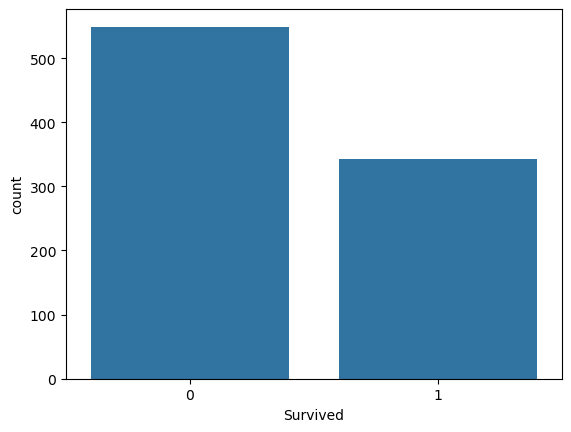

In [4]:
sb.countplot(x="Survived",data=td)

<Axes: xlabel='Pclass', ylabel='count'>

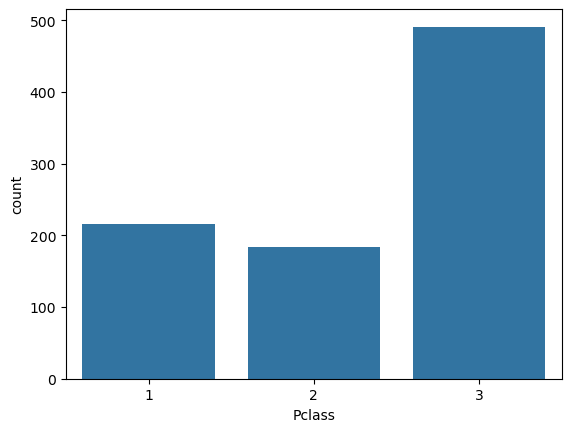

In [5]:
sb.countplot(x="Pclass", data=td)

<Axes: xlabel='Pclass', ylabel='count'>

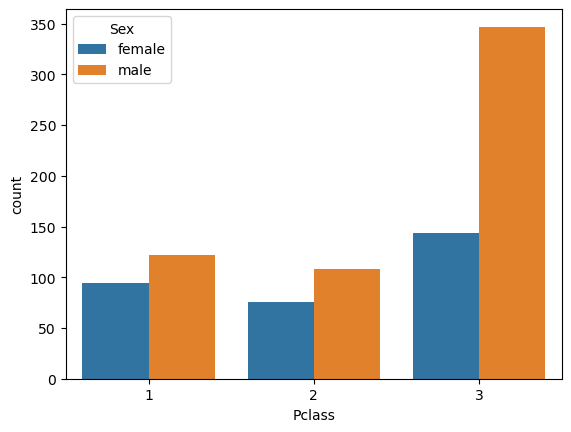

In [6]:
sb.countplot(x="Pclass", hue="Sex",data=td)

<Axes: xlabel='Survived', ylabel='count'>

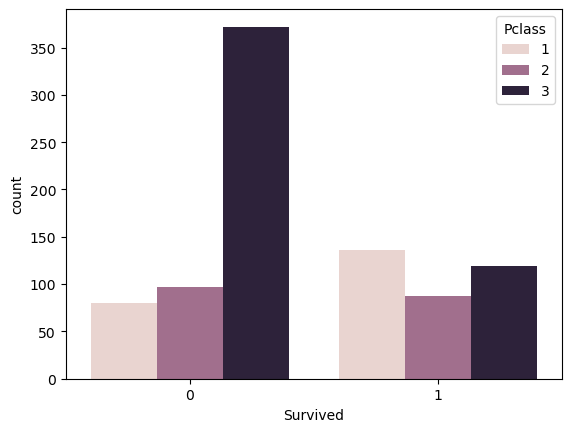

In [7]:
sb.countplot(x="Survived", hue="Pclass",data=td)

<Axes: xlabel='Survived', ylabel='count'>

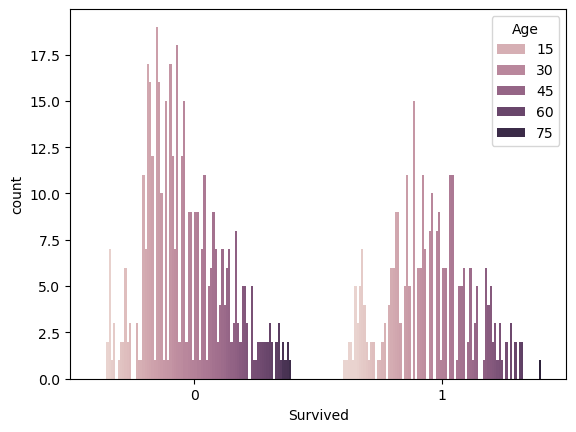

In [8]:
sb.countplot(x="Survived", hue="Age",data=td)

In [9]:
td.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
td.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
td.dropna(inplace=True)

In [12]:
td.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [13]:
td.isnull().info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  183 non-null    bool 
 1   Survived     183 non-null    bool 
 2   Pclass       183 non-null    bool 
 3   Name         183 non-null    bool 
 4   Sex          183 non-null    bool 
 5   Age          183 non-null    bool 
 6   SibSp        183 non-null    bool 
 7   Parch        183 non-null    bool 
 8   Ticket       183 non-null    bool 
 9   Fare         183 non-null    bool 
 10  Cabin        183 non-null    bool 
 11  Embarked     183 non-null    bool 
dtypes: bool(12)
memory usage: 3.6 KB


In [14]:
print(td['Sex'])

1      female
3      female
6        male
10     female
11     female
        ...  
871    female
872      male
879    female
887    female
889      male
Name: Sex, Length: 183, dtype: object


In [15]:
sex=pd.get_dummies(td['Sex'])

In [16]:
print(sex)

     female   male
1      True  False
3      True  False
6     False   True
10     True  False
11     True  False
..      ...    ...
871    True  False
872   False   True
879    True  False
887    True  False
889   False   True

[183 rows x 2 columns]


In [17]:
print(td['Embarked'])

1      C
3      S
6      S
10     S
11     S
      ..
871    S
872    S
879    C
887    S
889    C
Name: Embarked, Length: 183, dtype: object


In [18]:
emb=pd.get_dummies(td['Embarked'])

In [19]:
print(emb)

         C      Q      S
1     True  False  False
3    False  False   True
6    False  False   True
10   False  False   True
11   False  False   True
..     ...    ...    ...
871  False  False   True
872  False  False   True
879   True  False  False
887  False  False   True
889   True  False  False

[183 rows x 3 columns]


In [20]:
print(td['Pclass'])

1      1
3      1
6      1
10     3
11     1
      ..
871    1
872    1
879    1
887    1
889    1
Name: Pclass, Length: 183, dtype: int64


In [21]:
pcls=pd.get_dummies(td['Pclass'],prefix="Pclass")

In [22]:
print(pcls)

     Pclass_1  Pclass_2  Pclass_3
1        True     False     False
3        True     False     False
6        True     False     False
10      False     False      True
11       True     False     False
..        ...       ...       ...
871      True     False     False
872      True     False     False
879      True     False     False
887      True     False     False
889      True     False     False

[183 rows x 3 columns]


In [23]:
td.drop(["Pclass","Sex","Embarked"],axis=1,inplace=True)

In [24]:
td=pd.concat([td,sex,emb,pcls],axis=1)

In [25]:
print(td.info())

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Name         183 non-null    object 
 3   Age          183 non-null    float64
 4   SibSp        183 non-null    int64  
 5   Parch        183 non-null    int64  
 6   Ticket       183 non-null    object 
 7   Fare         183 non-null    float64
 8   Cabin        183 non-null    object 
 9   female       183 non-null    bool   
 10  male         183 non-null    bool   
 11  C            183 non-null    bool   
 12  Q            183 non-null    bool   
 13  S            183 non-null    bool   
 14  Pclass_1     183 non-null    bool   
 15  Pclass_2     183 non-null    bool   
 16  Pclass_3     183 non-null    bool   
dtypes: bool(8), float64(2), int64(4), object(3)
memory usage: 15.7+ KB
None


In [26]:
td.drop(["Name","PassengerId","Ticket","Cabin"],axis=1,inplace=True)

In [27]:
td.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  183 non-null    int64  
 1   Age       183 non-null    float64
 2   SibSp     183 non-null    int64  
 3   Parch     183 non-null    int64  
 4   Fare      183 non-null    float64
 5   female    183 non-null    bool   
 6   male      183 non-null    bool   
 7   C         183 non-null    bool   
 8   Q         183 non-null    bool   
 9   S         183 non-null    bool   
 10  Pclass_1  183 non-null    bool   
 11  Pclass_2  183 non-null    bool   
 12  Pclass_3  183 non-null    bool   
dtypes: bool(8), float64(2), int64(3)
memory usage: 10.0 KB


In [28]:
td.head(5)

,Survived,Age,SibSp,Parch,Fare,female,male,C,Q,S,Pclass_1,Pclass_2,Pclass_3
1,1,38.0,1,0,71.2833,True,False,True,False,False,True,False,False
3,1,35.0,1,0,53.1000,True,False,False,False,True,True,False,False
6,0,54.0,0,0,51.8625,False,True,False,False,True,True,False,False
10,1,4.0,1,1,16.7000,True,False,False,False,True,False,False,True
11,1,58.0,0,0,26.5500,True,False,False,False,True,True,False,False


In [29]:
X=td.drop(["Survived"],axis=1)

In [30]:
print(X)

      Age  SibSp  Parch     Fare  female   male      C      Q      S  \
1    38.0      1      0  71.2833    True  False   True  False  False   
3    35.0      1      0  53.1000    True  False  False  False   True   
6    54.0      0      0  51.8625   False   True  False  False   True   
10    4.0      1      1  16.7000    True  False  False  False   True   
11   58.0      0      0  26.5500    True  False  False  False   True   
..    ...    ...    ...      ...     ...    ...    ...    ...    ...   
871  47.0      1      1  52.5542    True  False  False  False   True   
872  33.0      0      0   5.0000   False   True  False  False   True   
879  56.0      0      1  83.1583    True  False   True  False  False   
887  19.0      0      0  30.0000    True  False  False  False   True   
889  26.0      0      0  30.0000   False   True   True  False  False   

     Pclass_1  Pclass_2  Pclass_3  
1        True     False     False  
3        True     False     False  
6        True     False    

In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       183 non-null    float64
 1   SibSp     183 non-null    int64  
 2   Parch     183 non-null    int64  
 3   Fare      183 non-null    float64
 4   female    183 non-null    bool   
 5   male      183 non-null    bool   
 6   C         183 non-null    bool   
 7   Q         183 non-null    bool   
 8   S         183 non-null    bool   
 9   Pclass_1  183 non-null    bool   
 10  Pclass_2  183 non-null    bool   
 11  Pclass_3  183 non-null    bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 8.6 KB


In [32]:
y=td["Survived"]

In [33]:
print(y)

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: Survived, Length: 183, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 356 to 218
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       128 non-null    float64
 1   SibSp     128 non-null    int64  
 2   Parch     128 non-null    int64  
 3   Fare      128 non-null    float64
 4   female    128 non-null    bool   
 5   male      128 non-null    bool   
 6   C         128 non-null    bool   
 7   Q         128 non-null    bool   
 8   S         128 non-null    bool   
 9   Pclass_1  128 non-null    bool   
 10  Pclass_2  128 non-null    bool   
 11  Pclass_3  128 non-null    bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 6.0 KB


In [37]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 297 to 645
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       55 non-null     float64
 1   SibSp     55 non-null     int64  
 2   Parch     55 non-null     int64  
 3   Fare      55 non-null     float64
 4   female    55 non-null     bool   
 5   male      55 non-null     bool   
 6   C         55 non-null     bool   
 7   Q         55 non-null     bool   
 8   S         55 non-null     bool   
 9   Pclass_1  55 non-null     bool   
 10  Pclass_2  55 non-null     bool   
 11  Pclass_3  55 non-null     bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 2.6 KB


In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
lm=LogisticRegression(max_iter=10000)

In [40]:
print(lm.fit(X_train,y_train))

LogisticRegression(max_iter=10000)


In [41]:
Predections=lm.predict(X_test)

In [42]:
from sklearn.metrics import classification_report

In [43]:
print(classification_report(y_test,Predections))

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        17
           1       0.79      0.82      0.81        38

    accuracy                           0.73        55
   macro avg       0.68      0.67      0.68        55
weighted avg       0.72      0.73      0.72        55



In [44]:
from sklearn.metrics import confusion_matrix

In [45]:
print(confusion_matrix(y_test,Predections))

[[ 9  8]
 [ 7 31]]


In [46]:
from sklearn.metrics import accuracy_score

In [47]:
print(accuracy_score(y_test,Predections))

0.7272727272727273


In [48]:
#import pickle

In [49]:
# save the model to disk
#with open('Titanic','wb') as f:
#   pickle.dump(td,f)


In [50]:
Predections

array([1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0], dtype=int64)

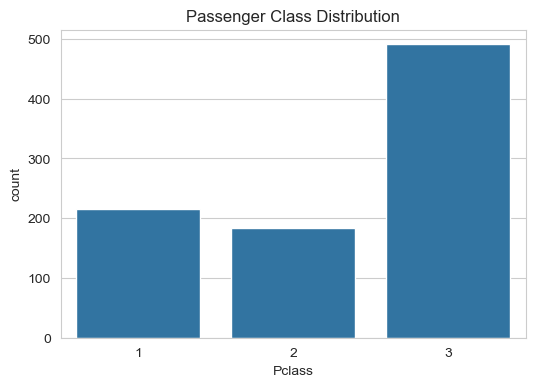

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

The bar chart titled "Survival Count" shows the number of passengers who survived (1) and did not survive (0) on the Titanic.

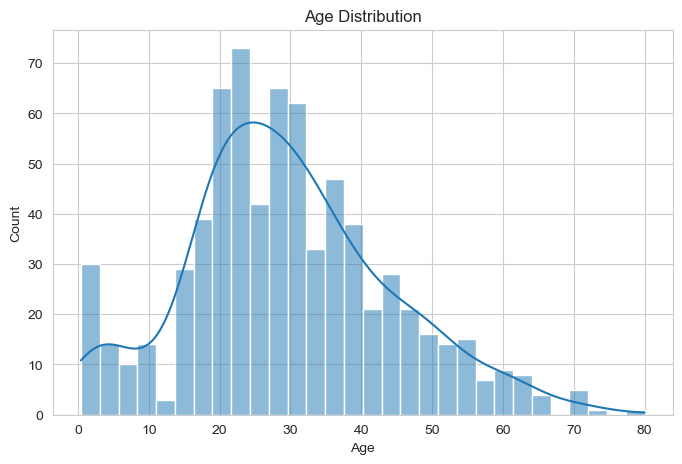

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

The chart titled "Age Distribution" is a histogram showing how passenger ages were spread on the Titanic, with a smooth curve (KDE) overlay for better trend visualization.

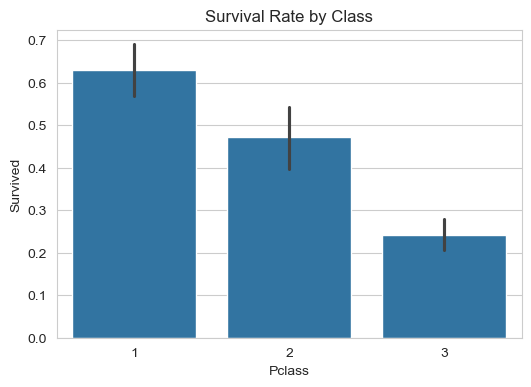

In [54]:
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Class")
plt.show()


The bar chart titled "Survival Rate by Class" shows how survival rates varied across the three passenger classes on the Titanic.

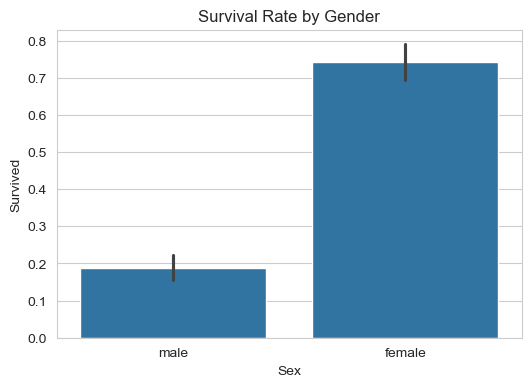

In [55]:
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

The chart titled "Survival Rate by Gender" illustrates how gender influenced the chances of survival on the Titanic.

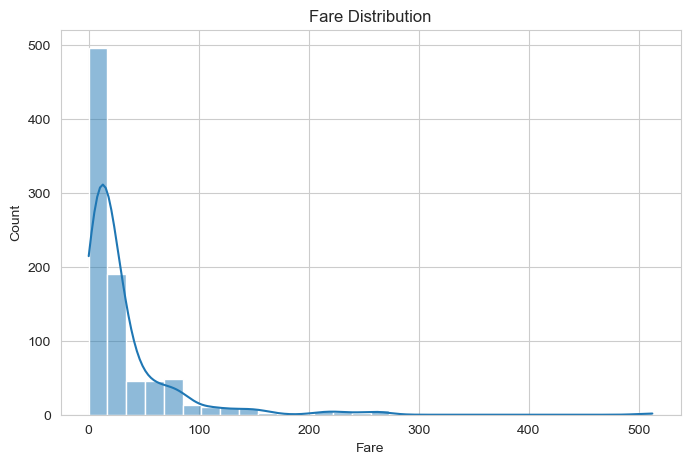

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

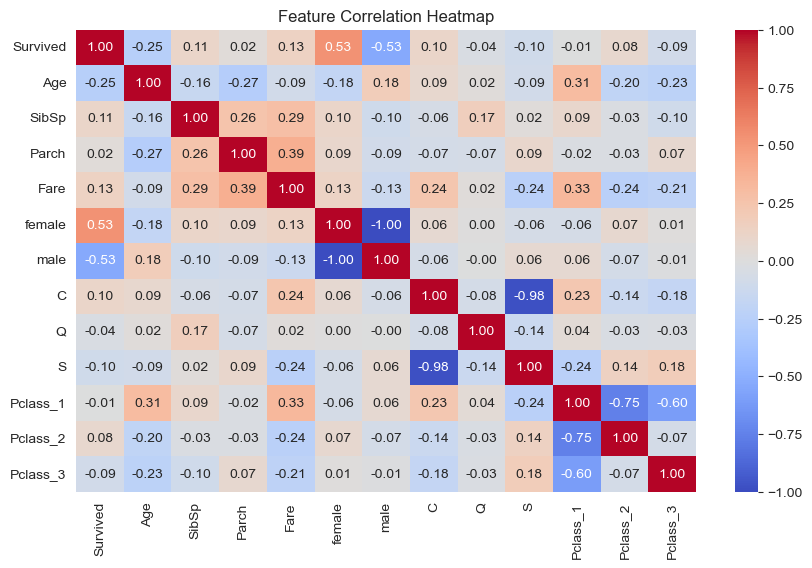

In [57]:
plt.figure(figsize=(10,6))
sns.heatmap(td.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

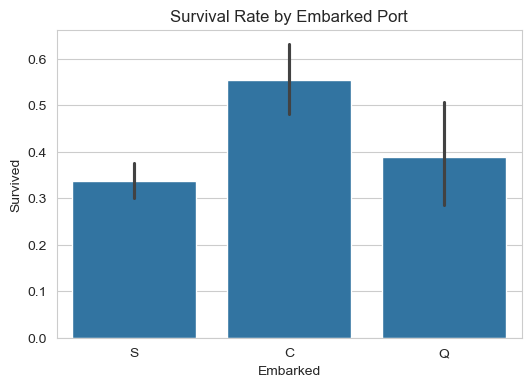

In [58]:
plt.figure(figsize=(6,4))
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Survival Rate by Embarked Port")
plt.show()

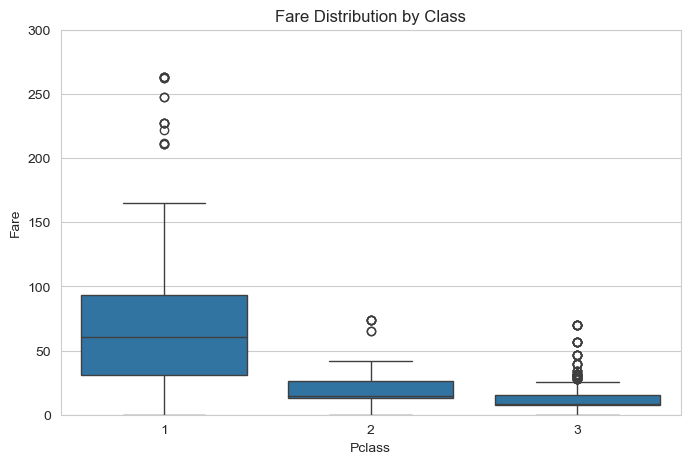

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Class")
plt.ylim(0, 300) 
plt.show()

This boxplot breaks down the fare distribution across passenger classes (Pclass) and visually highlights the economic divide on the Titanic.

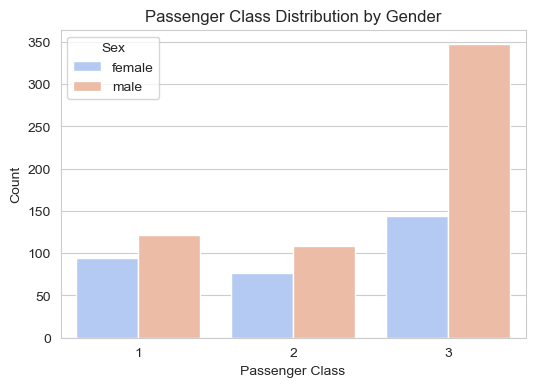

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Sex", data=df, palette="coolwarm")
plt.title("Passenger Class Distribution by Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

This bar chart displays the distribution of passenger class by gender, giving insight into how men and women were spread across the ship’s social structure.

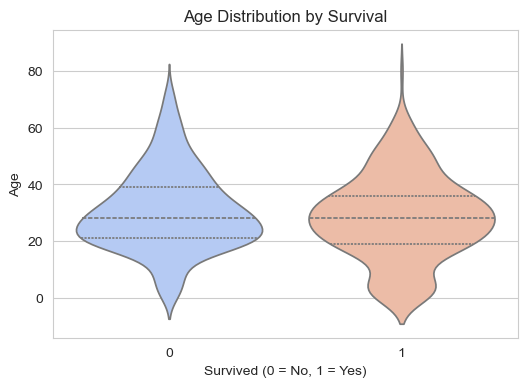

In [62]:
plt.figure(figsize=(6,4))
sns.violinplot(x="Survived", y="Age", data=df, palette="coolwarm", inner="quartile")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

This violin plot shows the age distribution of passengers based on survival.

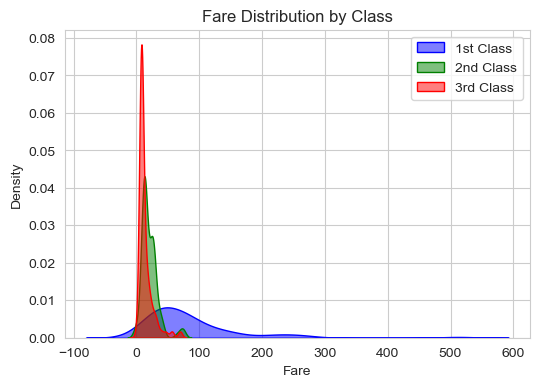

In [63]:
plt.figure(figsize=(6,4))
sns.kdeplot(df[df["Pclass"]==1]["Fare"], label="1st Class", fill=True, color="blue", alpha=0.5)
sns.kdeplot(df[df["Pclass"]==2]["Fare"], label="2nd Class", fill=True, color="green", alpha=0.5)
sns.kdeplot(df[df["Pclass"]==3]["Fare"], label="3rd Class", fill=True, color="red", alpha=0.5)
plt.title("Fare Distribution by Class")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.legend()
plt.show()

This density plot shows how fare prices were distributed across the three passenger classes on the Titanic.

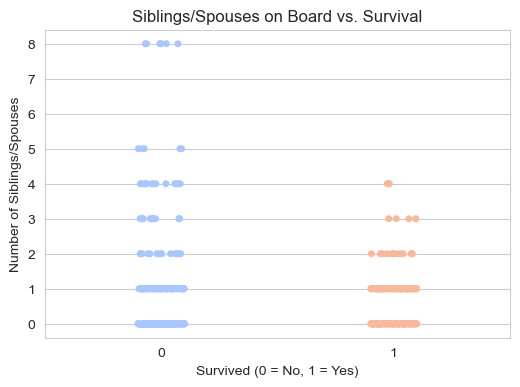

In [65]:
plt.figure(figsize=(6,4))
sns.stripplot(x="Survived", y="SibSp", data=df, jitter=True, palette="coolwarm")
plt.title("Siblings/Spouses on Board vs. Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Siblings/Spouses")
plt.show()

This plot shows the relationship between the number of siblings or spouses aboard (SibSp) and survival outcome.

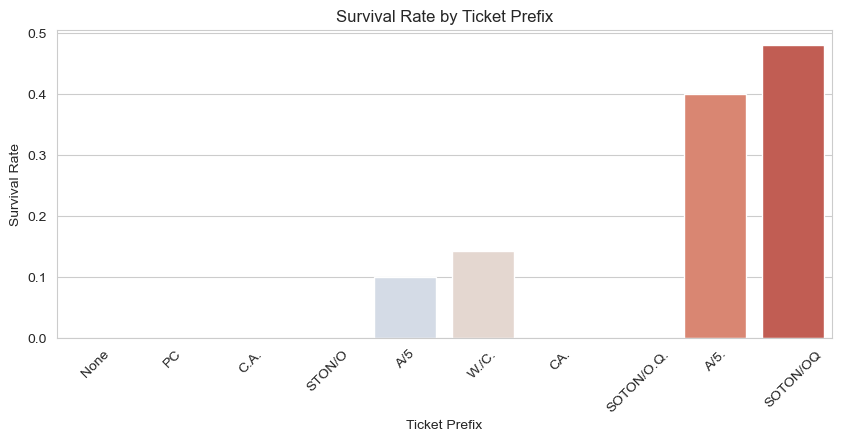

In [64]:
df["TicketPrefix"] = df["Ticket"].apply(lambda x: x.split()[0] if not x.isdigit() else "None")
plt.figure(figsize=(10,4))
sns.barplot(x=df["TicketPrefix"].value_counts().index[:10], 
            y=df.groupby("TicketPrefix")["Survived"].mean().values[:10], 
            palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Survival Rate by Ticket Prefix")
plt.xlabel("Ticket Prefix")
plt.ylabel("Survival Rate")
plt.show()

This bar chart illustrates the survival rate based on ticket prefixes, which likely reflect either the ticket issuer, location, or travel group.

FINAL OBSERVATIONS:
The analysis of the Titanic dataset reveals distinct patterns in survival outcomes based on passenger characteristics. Gender played a significant role—females had a much higher chance of survival compared to males, likely due to evacuation priorities. Passenger class also influenced outcomes, with first-class passengers enjoying better survival rates, suggesting the impact of socioeconomic status. Age was another key factor, where children, especially those traveling with family, were more likely to survive. Meanwhile, people traveling alone or in large family groups faced lower chances. The point of embarkation and the fare paid subtly influenced survival, with those paying higher fares (typically first-class) and those who embarked at Cherbourg faring better. Overall, the dataset underscores how social and demographic factors critically affected survival during the Titanic disaster.